# 🏀 NBA PLAYERS.CSV - KAPSAMLI OYUNCU PROFİL ANALİZİ

Bu notebook, **players.csv** dosyasını wget ile indirir ve çok detaylı oyuncu profil analizleri yapar.

## Dataset İçeriği
- **Oyuncu Bilgileri:** İsim, ID, takım bilgileri
- **Sezon Verileri:** Her oyuncunun hangi sezonlarda oynadığı
- **Takım Geçmişi:** Oyuncuların takım değişiklikleri
- **Kariyerleri:** Toplam sezon sayısı, takım sayısı

## Analiz Kapsamı
1. Veri indirme ve yükleme (Wget)
2. Temel keşifsel analiz
3. Detaylı eksik veri analizi
4. Oyuncu isim ve ID analizleri
5. Takım dağılımları ve transferler
6. Sezon bazlı analizler
7. Oyuncu kariyeri uzunluğu
8. Takım değişikliği analizleri
9. Sezon yoğunluğu analizi
10. En çok oynanan takımlar
11. Oyuncu kariyeri trendleri
12. Network analizi (oyuncu-takım)
13. Zaman serisi analizleri
14. İleri düzey içgörüler

## 📦 Kütüphane Kurulumu ve Import

In [1]:
# Gerekli kütüphaneler
import os
import subprocess
import zipfile
import glob
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Kütüphaneler başarıyla yüklendi!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'📈 NumPy version: {np.__version__}')
print(f'🎨 Matplotlib version: {plt.matplotlib.__version__}')
print(f'📊 Seaborn version: {sns.__version__}')

✅ Kütüphaneler başarıyla yüklendi!
📊 Pandas version: 2.2.2
📈 NumPy version: 2.0.2
🎨 Matplotlib version: 3.10.0
📊 Seaborn version: 0.13.2


## 📥 Dataset İndirme (Wget ile Kaggle)

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"🔽 {zip_filename} indiriliyor...")
    print(f"📍 URL: {download_url}")
    print(f"{'='*70}")
    print("⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ İndirme başarılı: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"🗑️ Zip silindi (disk alanı tasarrufu)")

        print(f"\n✅ Dataset hazır: {dest_folder}")
        return True
    except Exception as e:
        print(f"❌ Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "nba_games_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Dataset bilgileri
dataset_info = {
    "name": "nba-games",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games",
    "folder": dataset_folder,
    "zip_filename": "nba-games.zip"
}

# players.csv var mı kontrol et
players_path = os.path.join(dataset_folder, "players.csv")
if os.path.exists(players_path):
    print("\n" + "="*70)
    print("✅ Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("🏀 NBA GAMES DATASET İNDİRİLİYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("❌ MANUEL İNDİRME GEREKLİ")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/nathanlauga/nba-games")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. Zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu hücreyi tekrar çalıştırın")


🏀 NBA GAMES DATASET İNDİRİLİYOR

🔽 nba-games.zip indiriliyor...
📍 URL: https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games
⏳ Bu işlem birkaç dakika sürebilir...


✅ İndirme başarılı: nba_games_dataset/nba-games.zip

📦 Açılıyor: nba_games_dataset/nba-games.zip
🗑️ Zip silindi (disk alanı tasarrufu)

✅ Dataset hazır: nba_games_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("📂 DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  📄 {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("❌ CSV dosyaları bulunamadı!")


📂 DATASET DOSYALARI
  📄 games.csv                      -     3.92 MB
  📄 games_details.csv              -    88.77 MB
  📄 players.csv                    -     0.25 MB
  📄 ranking.csv                    -    14.73 MB
  📄 teams.csv                      -     0.00 MB


## 📊 PLAYERS.CSV - Veri Yükleme ve İlk Bakış

In [5]:
# players.csv dosyasını yükle
players_file = os.path.join(dataset_folder, "players.csv")
df = pd.read_csv(players_file)

print("="*70)
print("🏀 PLAYERS.CSV - TEMEL BİLGİLER")
print("="*70)
print(f"\n📌 Toplam Kayıt Sayısı: {len(df):,}")
print(f"📌 Sütun Sayısı: {len(df.columns)}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'PLAYER_NAME' in df.columns:
    print(f"\n👥 Benzersiz Oyuncu İsmi: {df['PLAYER_NAME'].nunique():,}")
if 'PLAYER_ID' in df.columns:
    print(f"👥 Benzersiz Oyuncu ID: {df['PLAYER_ID'].nunique():,}")
if 'TEAM_ID' in df.columns:
    print(f"🏆 Benzersiz Takım: {df['TEAM_ID'].nunique()}")
if 'SEASON' in df.columns:
    print(f"📅 Sezon Sayısı: {df['SEASON'].nunique()}")
    print(f"📅 Sezon Aralığı: {df['SEASON'].min()} - {df['SEASON'].max()}")

print(f"\n📋 Veri Şekli (shape): {df.shape}")
print("="*70)

🏀 PLAYERS.CSV - TEMEL BİLGİLER

📌 Toplam Kayıt Sayısı: 7,228
📌 Sütun Sayısı: 4
📌 Bellek Kullanımı: 0.59 MB

👥 Benzersiz Oyuncu İsmi: 1,749
👥 Benzersiz Oyuncu ID: 1,769
🏆 Benzersiz Takım: 30
📅 Sezon Sayısı: 11
📅 Sezon Aralığı: 2009 - 2019

📋 Veri Şekli (shape): (7228, 4)


In [6]:
# İlk 20 kayıt
print("\n📋 İLK 20 OYUNCU KAYDI:")
print("="*70)
df.head(20)


📋 İLK 20 OYUNCU KAYDI:


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
0,Royce O'Neale,1610612762,1626220,2019
1,Bojan Bogdanovic,1610612762,202711,2019
2,Rudy Gobert,1610612762,203497,2019
3,Donovan Mitchell,1610612762,1628378,2019
4,Mike Conley,1610612762,201144,2019
5,Joe Ingles,1610612762,204060,2019
6,Ed Davis,1610612762,202334,2019
7,Jeff Green,1610612762,201145,2019
8,Dante Exum,1610612762,203957,2019
9,Emmanuel Mudiay,1610612762,1626144,2019


In [7]:
# Son 20 kayıt
print("\n📋 SON 20 OYUNCU KAYDI:")
print("="*70)
df.tail(20)


📋 SON 20 OYUNCU KAYDI:


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
7208,Frank Robinson,1610612737,201648,2009
7209,Dontaye Draper,1610612743,202069,2009
7210,James White,1610612743,200778,2009
7211,Dwayne Jones,1610612759,101204,2009
7212,Aaron Miles,1610612737,101223,2009
7213,Michael Fey,1610612747,202071,2009
7214,Mickael Gelabale,1610612747,101153,2009
7215,Joe Crawford,1610612752,201621,2009
7216,Devin Green,1610612750,101209,2009
7217,David Monds,1610612747,201776,2009


In [8]:
# Rastgele 15 kayıt
print("\n📋 RASTGELE 15 KAYIT (Veri Çeşitliliği):")
print("="*70)
df.sample(15, random_state=42)


📋 RASTGELE 15 KAYIT (Veri Çeşitliliği):


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
2020,Sheldon Mac,1610612764,1627815,2017
6956,Yi Jianlian,1610612751,201146,2009
3043,Tibor Pleiss,1610612762,202353,2015
5495,Roy Hibbert,1610612754,201579,2011
1383,David West,1610612744,2561,2017
2423,Wesley Matthews,1610612742,202083,2016
5792,Jon Leuer,1610612749,202720,2011
6387,Stephen Jackson,1610612766,1536,2010
3733,Goran Dragic,1610612748,201609,2014
457,DeMarcus Cousins,1610612747,202326,2019


In [9]:
# Sütun tipleri ve bilgileri
print("\n" + "="*70)
print("📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ")
print("="*70)
df.info()


📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7228 entries, 0 to 7227
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PLAYER_NAME  7228 non-null   object
 1   TEAM_ID      7228 non-null   int64 
 2   PLAYER_ID    7228 non-null   int64 
 3   SEASON       7228 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 226.0+ KB


In [10]:
# Tüm sütun isimleri kategorize edilmiş
print("\n" + "="*70)
print(f"📝 TÜM SÜTUNLAR ({len(df.columns)} adet)")
print("="*70)

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    print(f"{i:2d}. {col:25} - Type: {str(dtype):10} - Unique: {unique:,}")


📝 TÜM SÜTUNLAR (4 adet)
 1. PLAYER_NAME               - Type: object     - Unique: 1,749
 2. TEAM_ID                   - Type: int64      - Unique: 30
 3. PLAYER_ID                 - Type: int64      - Unique: 1,769
 4. SEASON                    - Type: int64      - Unique: 11


In [11]:
# İstatistiksel özet
print("\n" + "="*70)
print("📈 İSTATİSTİKSEL ÖZET")
print("="*70)
df.describe(include='all').T


📈 İSTATİSTİKSEL ÖZET


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PLAYER_NAME,7228,1749,Chris Johnson,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TEAM_ID,7228.000,NaN,NaN,NaN,1610612751.369,8.724,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
PLAYER_ID,7228.000,NaN,NaN,NaN,2355861.976,61066884.734,244.000,200768.000,202346.500,203910.000,1962937827.000
SEASON,7228.000,NaN,NaN,NaN,2014.160,3.126,2009.000,2012.000,2014.000,2017.000,2019.000


## 🔍 Detaylı Eksik Veri Analizi

In [12]:
# Kapsamlı eksik veri analizi
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Sütun': missing_data.index,
    'Eksik_Sayı': missing_data.values,
    'Eksik_Yüzde': missing_pct.values,
    'Mevcut_Sayı': len(df) - missing_data.values,
    'Mevcut_Yüzde': 100 - missing_pct.values
}).sort_values('Eksik_Sayı', ascending=False)

print("="*70)
print("⚠️ DETAYLI EKSİK VERİ ANALİZİ")
print("="*70)

missing_cols = missing_df[missing_df['Eksik_Sayı'] > 0]
if len(missing_cols) > 0:
    print(f"\n❗ {len(missing_cols)} sütunda eksik veri tespit edildi:\n")
    print(missing_cols.to_string(index=False))

    print(f"\n📊 ÖZET İSTATİSTİKLER:")
    print(f"  Toplam Hücre: {len(df) * len(df.columns):,}")
    print(f"  Eksik Hücre: {missing_cols['Eksik_Sayı'].sum():,}")
    print(f"  Genel Eksiklik: {(missing_cols['Eksik_Sayı'].sum() / (len(df) * len(df.columns)) * 100):.2f}%")
else:
    print("\n✅ MÜKEMMEL! Hiç eksik veri yok.")
    print("Veri seti tamamen temiz ve eksiksiz.")

⚠️ DETAYLI EKSİK VERİ ANALİZİ

✅ MÜKEMMEL! Hiç eksik veri yok.
Veri seti tamamen temiz ve eksiksiz.


In [13]:
# Eksik veri görselleştirmesi
if len(missing_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Bar plot
    axes[0, 0].barh(range(len(missing_cols)), missing_cols['Eksik_Yüzde'],
                   color='crimson', edgecolor='black', alpha=0.7)
    axes[0, 0].set_yticks(range(len(missing_cols)))
    axes[0, 0].set_yticklabels(missing_cols['Sütun'])
    axes[0, 0].set_xlabel('Eksik Veri %')
    axes[0, 0].set_title('Eksik Veri Yüzdeleri', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Heatmap
    sample_size = min(500, len(df))
    sample_df = df.sample(sample_size, random_state=42)
    sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False,
               cmap='YlOrRd', ax=axes[0, 1])
    axes[0, 1].set_title(f'Eksik Veri Haritası ({sample_size} örnek)', fontweight='bold')

    # 3. Pie chart
    total_cells = len(df) * len(df.columns)
    missing_cells = missing_cols['Eksik_Sayı'].sum()
    present_cells = total_cells - missing_cells

    axes[1, 0].pie([present_cells, missing_cells],
                  labels=['Mevcut', 'Eksik'],
                  autopct='%1.2f%%', startangle=90,
                  colors=['lightgreen', 'lightcoral'])
    axes[1, 0].set_title('Genel Veri Durumu', fontweight='bold')

    # 4. Count plot
    axes[1, 1].bar(range(len(missing_cols)), missing_cols['Eksik_Sayı'],
                  color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xticks(range(len(missing_cols)))
    axes[1, 1].set_xticklabels(missing_cols['Sütun'], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Eksik Sayı')
    axes[1, 1].set_title('Eksik Veri Sayıları', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("✅ Eksik veri olmadığı için görselleştirme yapılmadı.")

✅ Eksik veri olmadığı için görselleştirme yapılmadı.


## 👥 Oyuncu İsim ve ID Analizleri

In [14]:
# Oyuncu isimleri detaylı analiz
if 'PLAYER_NAME' in df.columns:
    print("="*70)
    print("👥 OYUNCU İSİM ANALİZİ")
    print("="*70)

    unique_names = df['PLAYER_NAME'].nunique()
    total_records = len(df)

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Benzersiz Oyuncu: {unique_names:,}")
    print(f"  Toplam Kayıt: {total_records:,}")
    print(f"  Ort. Kayıt/Oyuncu: {total_records/unique_names:.2f}")

    # En sık görünen isimler
    name_counts = df['PLAYER_NAME'].value_counts()

    print(f"\n🔝 EN SIK GÖRÜLEN OYUNCULAR (Top 30):")
    print("="*70)
    for idx, (name, count) in enumerate(name_counts.head(30).items(), 1):
        print(f"{idx:2d}. {name:30} - {count:3d} kayıt")

    # İsim uzunluğu analizi
    df['name_length'] = df['PLAYER_NAME'].str.len()

    print(f"\n📏 İSİM UZUNLUĞU ANALİZİ:")
    print(f"  Ortalama: {df['name_length'].mean():.2f} karakter")
    print(f"  Medyan: {df['name_length'].median():.0f} karakter")
    print(f"  Min: {df['name_length'].min():.0f} ({df.loc[df['name_length'].idxmin(), 'PLAYER_NAME']})")
    print(f"  Max: {df['name_length'].max():.0f} ({df.loc[df['name_length'].idxmax(), 'PLAYER_NAME']})")

    # Kelime sayısı analizi
    df['name_words'] = df['PLAYER_NAME'].str.split().str.len()

    print(f"\n📝 KELİME SAYISI ANALİZİ:")
    word_dist = df['name_words'].value_counts().sort_index()
    for words, count in word_dist.items():
        pct = (count / len(df)) * 100
        print(f"  {words} kelime: {count:,} ({pct:.2f}%)")

👥 OYUNCU İSİM ANALİZİ

📊 Genel İstatistikler:
  Benzersiz Oyuncu: 1,749
  Toplam Kayıt: 7,228
  Ort. Kayıt/Oyuncu: 4.13

🔝 EN SIK GÖRÜLEN OYUNCULAR (Top 30):
 1. Chris Johnson                  -  18 kayıt
 2. Ish Smith                      -  17 kayıt
 3. Corey Brewer                   -  16 kayıt
 4. Garrett Temple                 -  16 kayıt
 5. Ersan Ilyasova                 -  15 kayıt
 6. Wesley Matthews                -  15 kayıt
 7. Anthony Tolliver               -  14 kayıt
 8. Jerryd Bayless                 -  14 kayıt
 9. D.J. Augustin                  -  14 kayıt
10. Courtney Lee                   -  14 kayıt
11. JaVale McGee                   -  13 kayıt
12. Lou Amundson                   -  13 kayıt
13. James Johnson                  -  13 kayıt
14. DeMarre Carroll                -  13 kayıt
15. Rudy Gay                       -  13 kayıt
16. Goran Dragic                   -  13 kayıt
17. Ramon Sessions                 -  13 kayıt
18. Beno Udrih                     -  13 ka

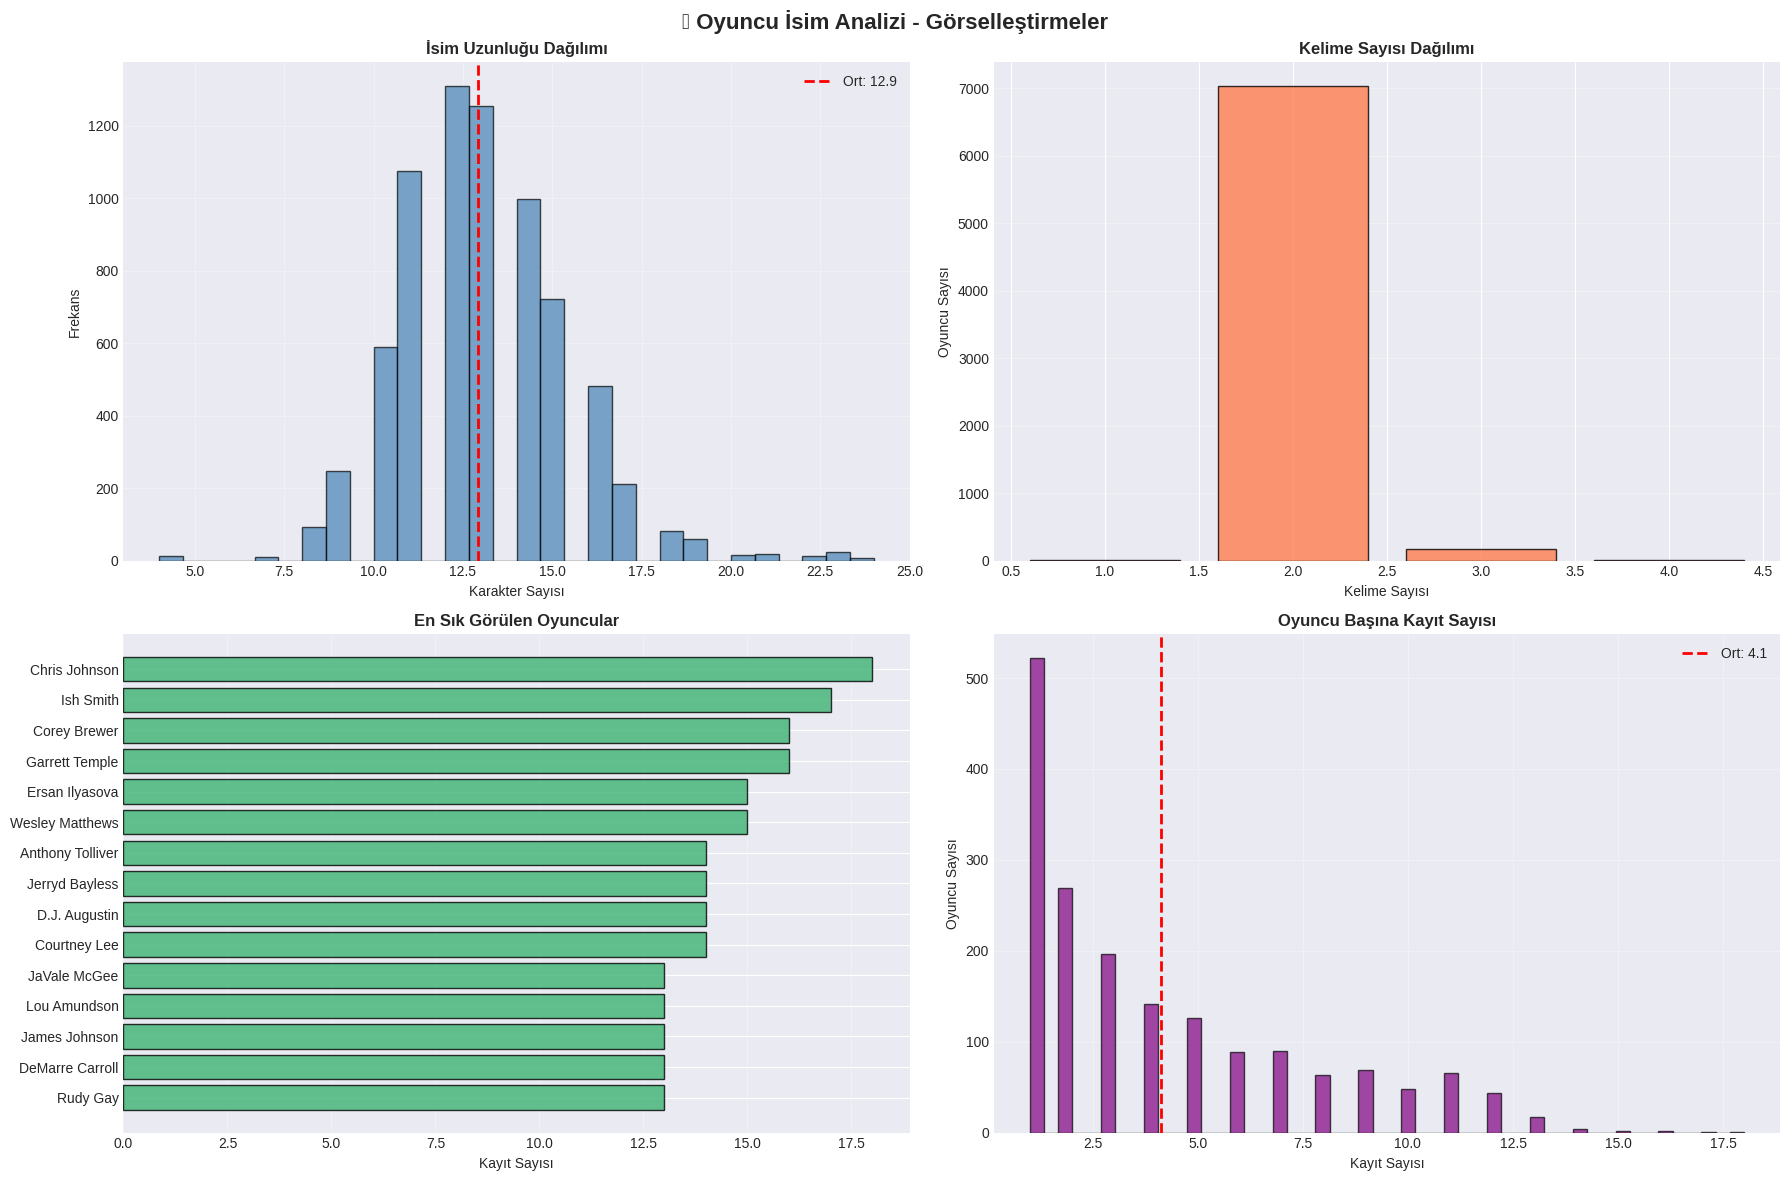

In [15]:
# İsim analizi görselleştirme
if 'name_length' in df.columns and 'name_words' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('👥 Oyuncu İsim Analizi - Görselleştirmeler',
                fontsize=16, fontweight='bold')

    # 1. İsim uzunluğu dağılımı
    axes[0, 0].hist(df['name_length'], bins=30, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['name_length'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['name_length'].mean():.1f}")
    axes[0, 0].set_title('İsim Uzunluğu Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Karakter Sayısı')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Kelime sayısı dağılımı
    word_counts = df['name_words'].value_counts().sort_index()
    axes[0, 1].bar(word_counts.index, word_counts.values,
                  color='coral', edgecolor='black', alpha=0.8)
    axes[0, 1].set_title('Kelime Sayısı Dağılımı', fontweight='bold')
    axes[0, 1].set_xlabel('Kelime Sayısı')
    axes[0, 1].set_ylabel('Oyuncu Sayısı')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. En sık oyuncular
    top_15 = df['PLAYER_NAME'].value_counts().head(15)
    axes[1, 0].barh(range(15), top_15.values, color='mediumseagreen',
                   edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(range(15))
    axes[1, 0].set_yticklabels(top_15.index)
    axes[1, 0].set_xlabel('Kayıt Sayısı')
    axes[1, 0].set_title('En Sık Görülen Oyuncular', fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)
    axes[1, 0].invert_yaxis()

    # 4. Kayıt sayısı dağılımı
    records_per_player = df['PLAYER_NAME'].value_counts()
    axes[1, 1].hist(records_per_player, bins=50, color='purple',
                   edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(records_per_player.mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {records_per_player.mean():.1f}")
    axes[1, 1].set_title('Oyuncu Başına Kayıt Sayısı', fontweight='bold')
    axes[1, 1].set_xlabel('Kayıt Sayısı')
    axes[1, 1].set_ylabel('Oyuncu Sayısı')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🏆 Takım Dağılımları ve Transferler

In [16]:
# Takım analizi
if 'TEAM_ID' in df.columns:
    print("="*70)
    print("🏆 TAKIM DAĞILIM ANALİZİ")
    print("="*70)

    team_counts = df['TEAM_ID'].value_counts()

    print(f"\n📊 Genel Bilgiler:")
    print(f"  Benzersiz Takım: {df['TEAM_ID'].nunique()}")
    print(f"  Toplam Kayıt: {len(df):,}")
    print(f"  Ort. Kayıt/Takım: {len(df) / df['TEAM_ID'].nunique():.2f}")

    print(f"\n🔝 EN FAZLA OYUNCUYA SAHİP TAKIMLAR (Top 30):")
    print("="*70)

    for idx, (team, count) in enumerate(team_counts.head(30).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{idx:2d}. Takım ID {team}: {count:4,} kayıt ({pct:5.2f}%)")

    print(f"\n🔻 EN AZ OYUNCUYA SAHİP TAKIMLAR (Top 10):")
    print("="*70)

    for idx, (team, count) in enumerate(team_counts.tail(10).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{idx:2d}. Takım ID {team}: {count:4,} kayıt ({pct:5.2f}%)")

🏆 TAKIM DAĞILIM ANALİZİ

📊 Genel Bilgiler:
  Benzersiz Takım: 30
  Toplam Kayıt: 7,228
  Ort. Kayıt/Takım: 240.93

🔝 EN FAZLA OYUNCUYA SAHİP TAKIMLAR (Top 30):
 1. Takım ID 1610612763:  276 kayıt ( 3.82%)
 2. Takım ID 1610612740:  275 kayıt ( 3.80%)
 3. Takım ID 1610612739:  272 kayıt ( 3.76%)
 4. Takım ID 1610612745:  265 kayıt ( 3.67%)
 5. Takım ID 1610612755:  263 kayıt ( 3.64%)
 6. Takım ID 1610612764:  257 kayıt ( 3.56%)
 7. Takım ID 1610612742:  250 kayıt ( 3.46%)
 8. Takım ID 1610612738:  250 kayıt ( 3.46%)
 9. Takım ID 1610612748:  249 kayıt ( 3.44%)
10. Takım ID 1610612751:  248 kayıt ( 3.43%)
11. Takım ID 1610612737:  245 kayıt ( 3.39%)
12. Takım ID 1610612749:  243 kayıt ( 3.36%)
13. Takım ID 1610612752:  242 kayıt ( 3.35%)
14. Takım ID 1610612756:  240 kayıt ( 3.32%)
15. Takım ID 1610612758:  239 kayıt ( 3.31%)
16. Takım ID 1610612762:  239 kayıt ( 3.31%)
17. Takım ID 1610612760:  238 kayıt ( 3.29%)
18. Takım ID 1610612744:  238 kayıt ( 3.29%)
19. Takım ID 1610612759:  236 

In [17]:
# Oyuncu başına takım sayısı
if 'PLAYER_NAME' in df.columns and 'TEAM_ID' in df.columns:
    teams_per_player = df.groupby('PLAYER_NAME')['TEAM_ID'].nunique()

    print("\n" + "="*70)
    print("🔄 OYUNCU BAŞINA TAKIM SAYISI ANALİZİ")
    print("="*70)

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Ortalama: {teams_per_player.mean():.2f} takım/oyuncu")
    print(f"  Medyan: {teams_per_player.median():.0f} takım")
    print(f"  Min: {teams_per_player.min()} takım")
    print(f"  Max: {teams_per_player.max()} takım")
    print(f"  Std Sapma: {teams_per_player.std():.2f}")

    # Dağılım
    team_dist = teams_per_player.value_counts().sort_index()
    print(f"\n📊 DAĞILIM:")
    for num_teams, count in team_dist.items():
        pct = (count / len(teams_per_player)) * 100
        print(f"  {num_teams:2d} takım: {count:4,} oyuncu ({pct:5.2f}%)")

    # En çok takım değiştiren oyuncular
    most_teams = teams_per_player.nlargest(20)
    print(f"\n🔝 EN ÇOK TAKIM DEĞİŞTİREN OYUNCULAR (Top 20):")
    print("="*70)
    for idx, (player, num_teams) in enumerate(most_teams.items(), 1):
        print(f"{idx:2d}. {player:30} - {num_teams} takım")


🔄 OYUNCU BAŞINA TAKIM SAYISI ANALİZİ

📊 Genel İstatistikler:
  Ortalama: 2.44 takım/oyuncu
  Medyan: 2 takım
  Min: 1 takım
  Max: 13 takım
  Std Sapma: 1.77

📊 DAĞILIM:
   1 takım:  737 oyuncu (42.14%)
   2 takım:  386 oyuncu (22.07%)
   3 takım:  222 oyuncu (12.69%)
   4 takım:  162 oyuncu ( 9.26%)
   5 takım:  116 oyuncu ( 6.63%)
   6 takım:   62 oyuncu ( 3.54%)
   7 takım:   36 oyuncu ( 2.06%)
   8 takım:   19 oyuncu ( 1.09%)
   9 takım:    5 oyuncu ( 0.29%)
  10 takım:    2 oyuncu ( 0.11%)
  11 takım:    1 oyuncu ( 0.06%)
  13 takım:    1 oyuncu ( 0.06%)

🔝 EN ÇOK TAKIM DEĞİŞTİREN OYUNCULAR (Top 20):
 1. Chris Johnson                  - 13 takım
 2. Ish Smith                      - 11 takım
 3. Garrett Temple                 - 10 takım
 4. Justin Holiday                 - 10 takım
 5. Anthony Tolliver               - 9 takım
 6. Corey Brewer                   - 9 takım
 7. Lou Amundson                   - 9 takım
 8. Toney Douglas                  - 9 takım
 9. Wayne Ellington   

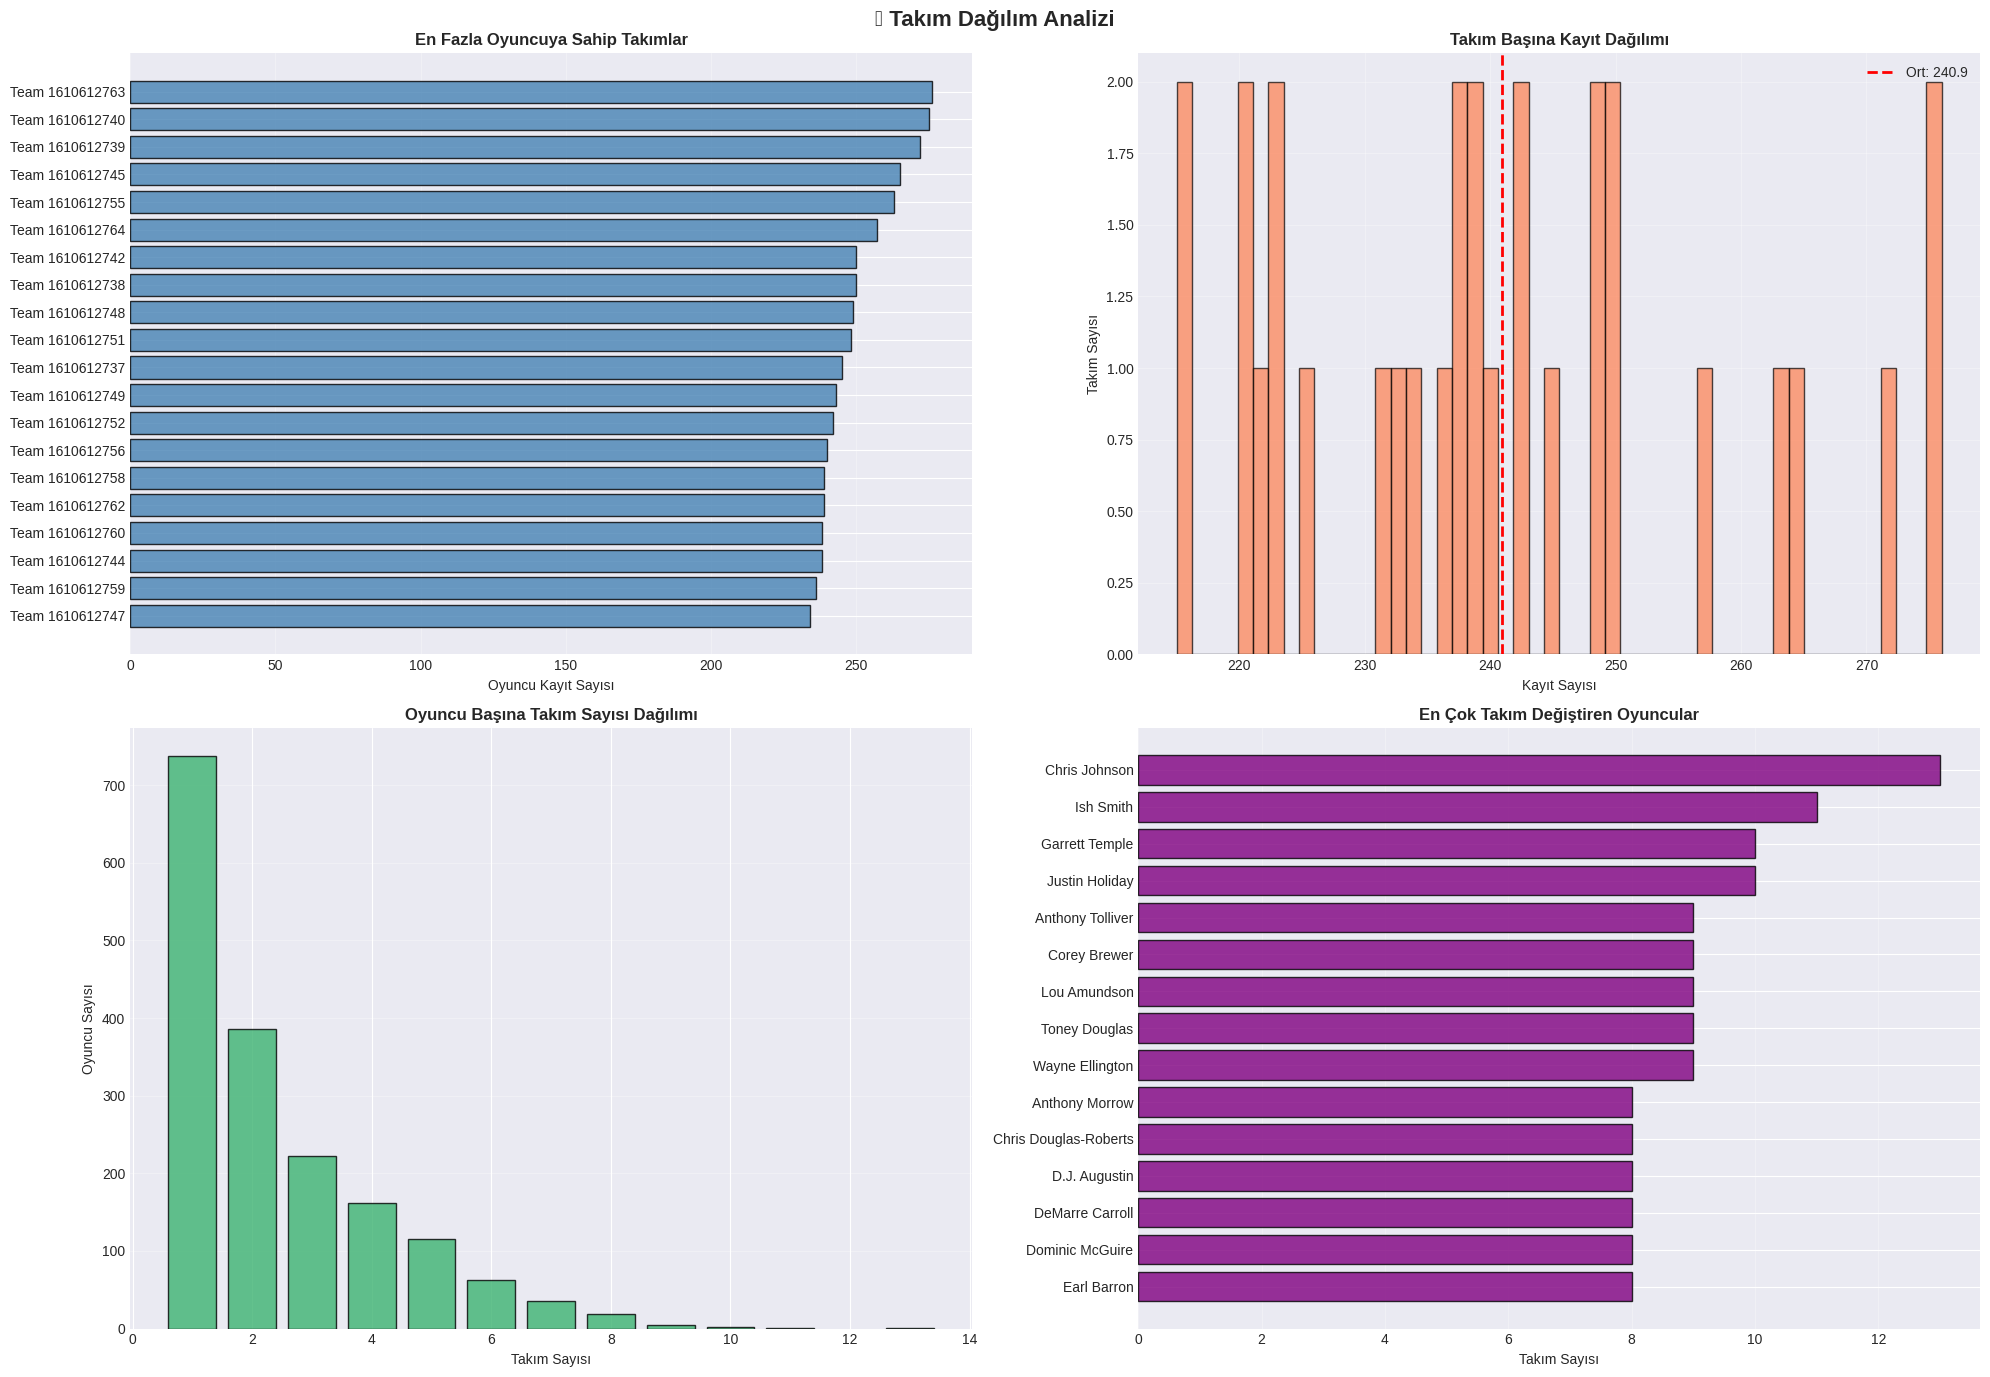

In [18]:
# Takım dağılımı görselleştirmesi
if 'TEAM_ID' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('🏆 Takım Dağılım Analizi', fontsize=16, fontweight='bold')

    # 1. En fazla oyuncuya sahip takımlar
    top_20_teams = team_counts.head(20)
    axes[0, 0].barh(range(20), top_20_teams.values, color='steelblue',
                   edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(20))
    axes[0, 0].set_yticklabels([f"Team {tid}" for tid in top_20_teams.index])
    axes[0, 0].set_xlabel('Oyuncu Kayıt Sayısı')
    axes[0, 0].set_title('En Fazla Oyuncuya Sahip Takımlar', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Takım başına oyuncu dağılımı
    axes[0, 1].hist(team_counts.values, bins=50, color='coral',
                   edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(team_counts.mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {team_counts.mean():.1f}")
    axes[0, 1].set_title('Takım Başına Kayıt Dağılımı', fontweight='bold')
    axes[0, 1].set_xlabel('Kayıt Sayısı')
    axes[0, 1].set_ylabel('Takım Sayısı')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Oyuncu başına takım sayısı
    if 'PLAYER_NAME' in df.columns:
        team_dist = teams_per_player.value_counts().sort_index()
        axes[1, 0].bar(team_dist.index, team_dist.values, color='mediumseagreen',
                      edgecolor='black', alpha=0.8)
        axes[1, 0].set_title('Oyuncu Başına Takım Sayısı Dağılımı', fontweight='bold')
        axes[1, 0].set_xlabel('Takım Sayısı')
        axes[1, 0].set_ylabel('Oyuncu Sayısı')
        axes[1, 0].grid(axis='y', alpha=0.3)

        # 4. En çok takım değiştirenler
        most_teams_top15 = teams_per_player.nlargest(15)
        axes[1, 1].barh(range(15), most_teams_top15.values, color='purple',
                       edgecolor='black', alpha=0.8)
        axes[1, 1].set_yticks(range(15))
        axes[1, 1].set_yticklabels(most_teams_top15.index)
        axes[1, 1].set_xlabel('Takım Sayısı')
        axes[1, 1].set_title('En Çok Takım Değiştiren Oyuncular', fontweight='bold')
        axes[1, 1].grid(axis='x', alpha=0.3)
        axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 📅 Sezon Bazlı Detaylı Analizler

In [19]:
# Sezon analizi
if 'SEASON' in df.columns:
    print("="*70)
    print("📅 SEZON BAZLI ANALİZ")
    print("="*70)

    season_counts = df['SEASON'].value_counts().sort_index()

    print(f"\n📊 Genel Bilgiler:")
    print(f"  Sezon Sayısı: {df['SEASON'].nunique()}")
    print(f"  İlk Sezon: {df['SEASON'].min()}")
    print(f"  Son Sezon: {df['SEASON'].max()}")
    print(f"  Kapsam: {df['SEASON'].max() - df['SEASON'].min() + 1} sezon")
    print(f"  Ort. Kayıt/Sezon: {len(df) / df['SEASON'].nunique():.2f}")

    print(f"\n📊 SEZON BAZINDA KAYIT SAYILARI:")
    print("="*70)

    cumulative = 0
    for season, count in season_counts.items():
        cumulative += count
        pct = (count / len(df)) * 100
        cum_pct = (cumulative / len(df)) * 100
        print(f"  {season}: {count:5,} kayıt ({pct:5.2f}%) - Kümülatif: {cumulative:6,} ({cum_pct:5.2f}%)")

📅 SEZON BAZLI ANALİZ

📊 Genel Bilgiler:
  Sezon Sayısı: 11
  İlk Sezon: 2009
  Son Sezon: 2019
  Kapsam: 11 sezon
  Ort. Kayıt/Sezon: 657.09

📊 SEZON BAZINDA KAYIT SAYILARI:
  2009:   597 kayıt ( 8.26%) - Kümülatif:    597 ( 8.26%)
  2010:   623 kayıt ( 8.62%) - Kümülatif:  1,220 (16.88%)
  2011:   582 kayıt ( 8.05%) - Kümülatif:  1,802 (24.93%)
  2012:   637 kayıt ( 8.81%) - Kümülatif:  2,439 (33.74%)
  2013:   653 kayıt ( 9.03%) - Kümülatif:  3,092 (42.78%)
  2014:   697 kayıt ( 9.64%) - Kümülatif:  3,789 (52.42%)
  2015:   668 kayıt ( 9.24%) - Kümülatif:  4,457 (61.66%)
  2016:   675 kayıt ( 9.34%) - Kümülatif:  5,132 (71.00%)
  2017:   722 kayıt ( 9.99%) - Kümülatif:  5,854 (80.99%)
  2018:   748 kayıt (10.35%) - Kümülatif:  6,602 (91.34%)
  2019:   626 kayıt ( 8.66%) - Kümülatif:  7,228 (100.00%)


In [20]:
# Oyuncu başına sezon sayısı
if 'PLAYER_NAME' in df.columns and 'SEASON' in df.columns:
    seasons_per_player = df.groupby('PLAYER_NAME')['SEASON'].nunique()

    print("\n" + "="*70)
    print("🏀 OYUNCU KARİYER UZUNLUĞU ANALİZİ (Sezon Bazlı)")
    print("="*70)

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Ortalama Kariyer: {seasons_per_player.mean():.2f} sezon")
    print(f"  Medyan Kariyer: {seasons_per_player.median():.0f} sezon")
    print(f"  Min Kariyer: {seasons_per_player.min()} sezon")
    print(f"  Max Kariyer: {seasons_per_player.max()} sezon")
    print(f"  Std Sapma: {seasons_per_player.std():.2f}")
    print(f"  Q1 (25%): {seasons_per_player.quantile(0.25):.0f} sezon")
    print(f"  Q3 (75%): {seasons_per_player.quantile(0.75):.0f} sezon")

    # Kariyer dağılımı
    career_dist = seasons_per_player.value_counts().sort_index()
    print(f"\n📊 KARİYER UZUNLUĞU DAĞILIMI:")
    for seasons, count in career_dist.head(20).items():
        pct = (count / len(seasons_per_player)) * 100
        print(f"  {seasons:2d} sezon: {count:4,} oyuncu ({pct:5.2f}%)")

    # En uzun kariyerli oyuncular
    longest_careers = seasons_per_player.nlargest(30)
    print(f"\n👑 EN UZUN KARİYERLİ OYUNCULAR (Top 30):")
    print("="*70)
    for idx, (player, seasons) in enumerate(longest_careers.items(), 1):
        print(f"{idx:2d}. {player:30} - {seasons} sezon")


🏀 OYUNCU KARİYER UZUNLUĞU ANALİZİ (Sezon Bazlı)

📊 Genel İstatistikler:
  Ortalama Kariyer: 3.59 sezon
  Medyan Kariyer: 3 sezon
  Min Kariyer: 1 sezon
  Max Kariyer: 11 sezon
  Std Sapma: 2.89
  Q1 (25%): 1 sezon
  Q3 (75%): 5 sezon

📊 KARİYER UZUNLUĞU DAĞILIMI:
   1 sezon:  558 oyuncu (31.90%)
   2 sezon:  308 oyuncu (17.61%)
   3 sezon:  211 oyuncu (12.06%)
   4 sezon:  164 oyuncu ( 9.38%)
   5 sezon:  107 oyuncu ( 6.12%)
   6 sezon:   85 oyuncu ( 4.86%)
   7 sezon:   81 oyuncu ( 4.63%)
   8 sezon:   74 oyuncu ( 4.23%)
   9 sezon:   52 oyuncu ( 2.97%)
  10 sezon:   47 oyuncu ( 2.69%)
  11 sezon:   62 oyuncu ( 3.54%)

👑 EN UZUN KARİYERLİ OYUNCULAR (Top 30):
 1. Al Horford                     - 11 sezon
 2. Andre Iguodala                 - 11 sezon
 3. Anthony Tolliver               - 11 sezon
 4. Blake Griffin                  - 11 sezon
 5. Brook Lopez                    - 11 sezon
 6. CJ Miles                       - 11 sezon
 7. Carmelo Anthony                - 11 sezon
 8. Chris

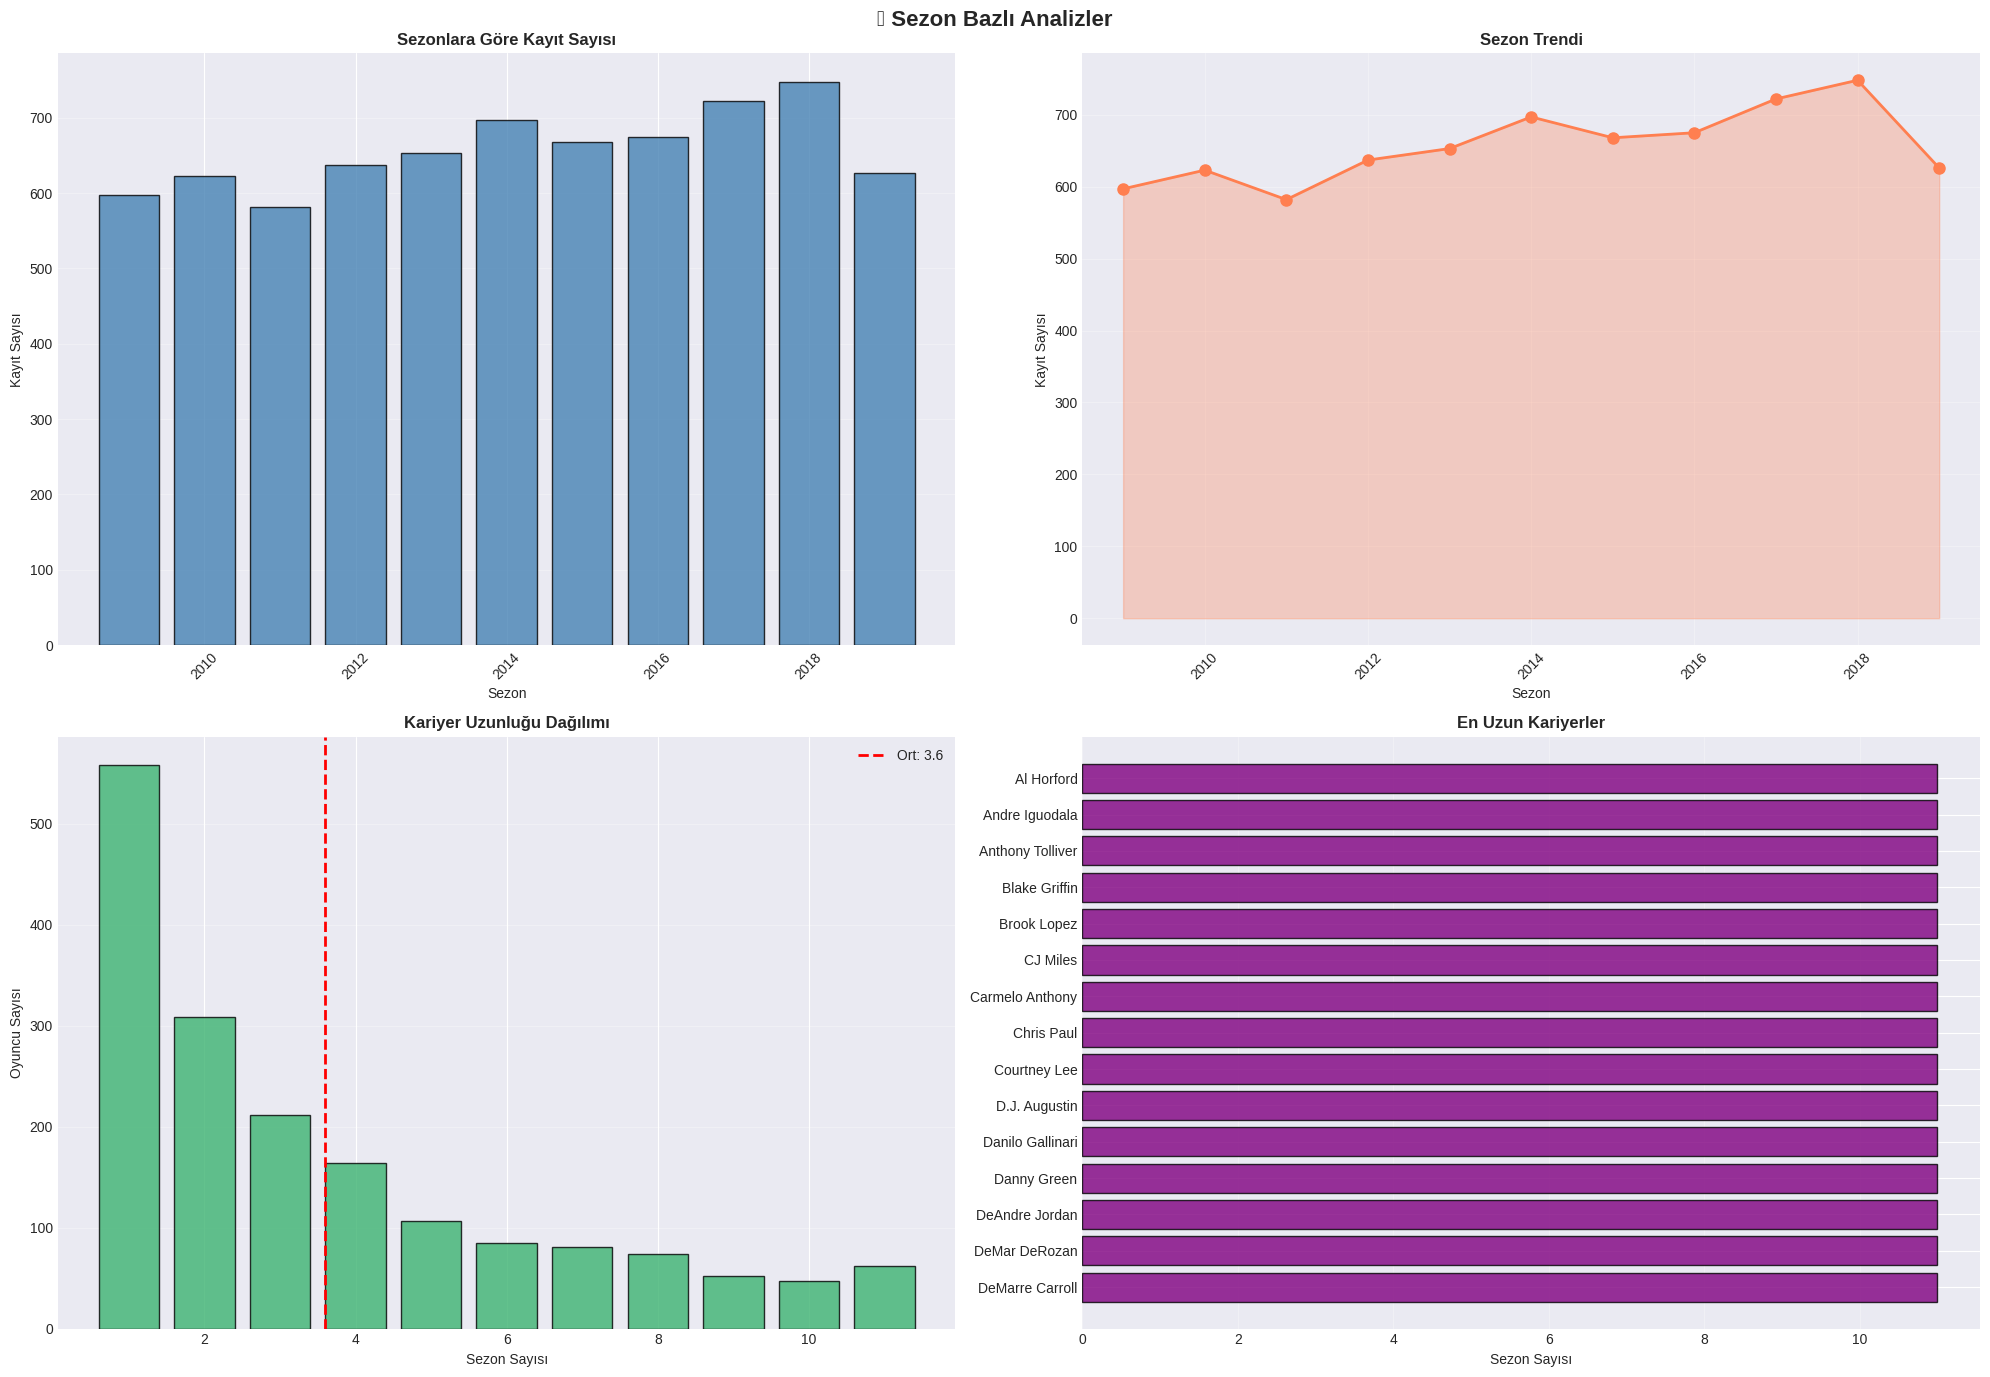

In [21]:
# Sezon görselleştirmeleri
if 'SEASON' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('📅 Sezon Bazlı Analizler', fontsize=16, fontweight='bold')

    # 1. Sezonlara göre kayıt sayısı
    axes[0, 0].bar(season_counts.index, season_counts.values,
                  color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_title('Sezonlara Göre Kayıt Sayısı', fontweight='bold')
    axes[0, 0].set_xlabel('Sezon')
    axes[0, 0].set_ylabel('Kayıt Sayısı')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Sezon tren çizgisi
    axes[0, 1].plot(season_counts.index, season_counts.values,
                   marker='o', linewidth=2, markersize=8, color='coral')
    axes[0, 1].fill_between(season_counts.index, season_counts.values,
                            alpha=0.3, color='coral')
    axes[0, 1].set_title('Sezon Trendi', fontweight='bold')
    axes[0, 1].set_xlabel('Sezon')
    axes[0, 1].set_ylabel('Kayıt Sayısı')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. Kariyer uzunluğu dağılımı
    if 'PLAYER_NAME' in df.columns:
        career_dist = seasons_per_player.value_counts().sort_index()
        axes[1, 0].bar(career_dist.index, career_dist.values,
                      color='mediumseagreen', edgecolor='black', alpha=0.8)
        axes[1, 0].axvline(seasons_per_player.mean(), color='red', linestyle='--',
                          linewidth=2, label=f"Ort: {seasons_per_player.mean():.1f}")
        axes[1, 0].set_title('Kariyer Uzunluğu Dağılımı', fontweight='bold')
        axes[1, 0].set_xlabel('Sezon Sayısı')
        axes[1, 0].set_ylabel('Oyuncu Sayısı')
        axes[1, 0].legend()
        axes[1, 0].grid(axis='y', alpha=0.3)

        # 4. En uzun kariyerler
        longest_15 = seasons_per_player.nlargest(15)
        axes[1, 1].barh(range(15), longest_15.values, color='purple',
                       edgecolor='black', alpha=0.8)
        axes[1, 1].set_yticks(range(15))
        axes[1, 1].set_yticklabels(longest_15.index)
        axes[1, 1].set_xlabel('Sezon Sayısı')
        axes[1, 1].set_title('En Uzun Kariyerler', fontweight='bold')
        axes[1, 1].grid(axis='x', alpha=0.3)
        axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 🔄 Oyuncu-Takım İlişkisi ve Transfer Analizi

In [22]:
# Her oyuncunun takım geçmişi
if all(col in df.columns for col in ['PLAYER_NAME', 'TEAM_ID', 'SEASON']):
    print("="*70)
    print("🔄 TRANSFER VE TAKIM GEÇMİŞİ ANALİZİ")
    print("="*70)

    # Her oyuncu için takım-sezon kombinasyonlarını grupla
    player_team_seasons = df.groupby('PLAYER_NAME').apply(
        lambda x: x.groupby('TEAM_ID')['SEASON'].nunique().to_dict()
    )

    # Tek sezonda birden fazla takımda oynayan oyuncular
    multi_team_seasons = df.groupby(['PLAYER_NAME', 'SEASON'])['TEAM_ID'].nunique()
    traded_mid_season = multi_team_seasons[multi_team_seasons > 1]

    print(f"\n📊 Transfer İstatistikleri:")
    print(f"  Sezon içi transfer yapan oyuncu-sezon: {len(traded_mid_season):,}")
    print(f"  Benzersiz oyuncu (sezon içi transfer): {traded_mid_season.index.get_level_values(0).nunique():,}")

    if len(traded_mid_season) > 0:
        # En çok sezon içi transfer yapanlar
        player_mid_season_trades = traded_mid_season.groupby(level=0).size().sort_values(ascending=False)

        print(f"\n🔝 EN ÇOK SEZON İÇİ TRANSFER YAPAN OYUNCULAR (Top 20):")
        print("="*70)
        for idx, (player, count) in enumerate(player_mid_season_trades.head(20).items(), 1):
            print(f"{idx:2d}. {player:30} - {count} sezon")

🔄 TRANSFER VE TAKIM GEÇMİŞİ ANALİZİ

📊 Transfer İstatistikleri:
  Sezon içi transfer yapan oyuncu-sezon: 826
  Benzersiz oyuncu (sezon içi transfer): 582

🔝 EN ÇOK SEZON İÇİ TRANSFER YAPAN OYUNCULAR (Top 20):
 1. Chris Johnson                  - 6 sezon
 2. Corey Brewer                   - 5 sezon
 3. Ish Smith                      - 5 sezon
 4. Beno Udrih                     - 4 sezon
 5. Ramon Sessions                 - 4 sezon
 6. Steve Novak                    - 4 sezon
 7. Toney Douglas                  - 4 sezon
 8. Garrett Temple                 - 4 sezon
 9. Marcus Thornton                - 4 sezon
10. Tobias Harris                  - 4 sezon
11. Andre Miller                   - 3 sezon
12. Terrence Williams              - 3 sezon
13. Shavlik Randolph               - 3 sezon
14. Brandan Wright                 - 3 sezon
15. Reggie Williams                - 3 sezon
16. Tim Frazier                    - 3 sezon
17. Shelvin Mack                   - 3 sezon
18. Sean Kilpatrick       

In [23]:
# Oyuncu sadakat analizi (tek takımda kalanlar)
if 'PLAYER_NAME' in df.columns and 'TEAM_ID' in df.columns:
    loyalty_analysis = df.groupby('PLAYER_NAME').agg({
        'TEAM_ID': 'nunique',
        'SEASON': 'nunique'
    }).rename(columns={'TEAM_ID': 'num_teams', 'SEASON': 'num_seasons'})

    # Tek takımda oynayan oyuncular
    one_team_players = loyalty_analysis[loyalty_analysis['num_teams'] == 1]

    print("\n" + "="*70)
    print("💙 OYUNCU SADAKAT ANALİZİ (Tek Takım)")
    print("="*70)

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Tek takımda kalan oyuncu: {len(one_team_players):,}")
    print(f"  Toplam oyuncu: {len(loyalty_analysis):,}")
    print(f"  Sadakat oranı: {len(one_team_players)/len(loyalty_analysis)*100:.2f}%")

    # En uzun tek takım kariyerleri
    longest_loyalty = one_team_players.nlargest(30, 'num_seasons')

    print(f"\n👑 EN UZUN TEK TAKIM KARİYERLERİ (Top 30):")
    print("="*70)
    for idx, (player, row) in enumerate(longest_loyalty.iterrows(), 1):
        print(f"{idx:2d}. {player:30} - {row['num_seasons']} sezon")


💙 OYUNCU SADAKAT ANALİZİ (Tek Takım)

📊 Genel İstatistikler:
  Tek takımda kalan oyuncu: 737
  Toplam oyuncu: 1,749
  Sadakat oranı: 42.14%

👑 EN UZUN TEK TAKIM KARİYERLERİ (Top 30):
 1. Stephen Curry                  - 11 sezon
 2. Udonis Haslem                  - 11 sezon
 3. Dirk Nowitzki                  - 10 sezon
 4. John Wall                      - 10 sezon
 5. Klay Thompson                  - 9 sezon
 6. Manu Ginobili                  - 9 sezon
 7. Nick Collison                  - 9 sezon
 8. Tristan Thompson               - 9 sezon
 9. Andre Drummond                 - 8 sezon
10. Bradley Beal                   - 8 sezon
11. Damian Lillard                 - 8 sezon
12. Draymond Green                 - 8 sezon
13. Michael Kidd-Gilchrist         - 8 sezon
14. Andre Roberson                 - 7 sezon
15. CJ McCollum                    - 7 sezon
16. Cody Zeller                    - 7 sezon
17. Giannis Antetokounmpo          - 7 sezon
18. Gorgui Dieng                   - 7 sezon
19

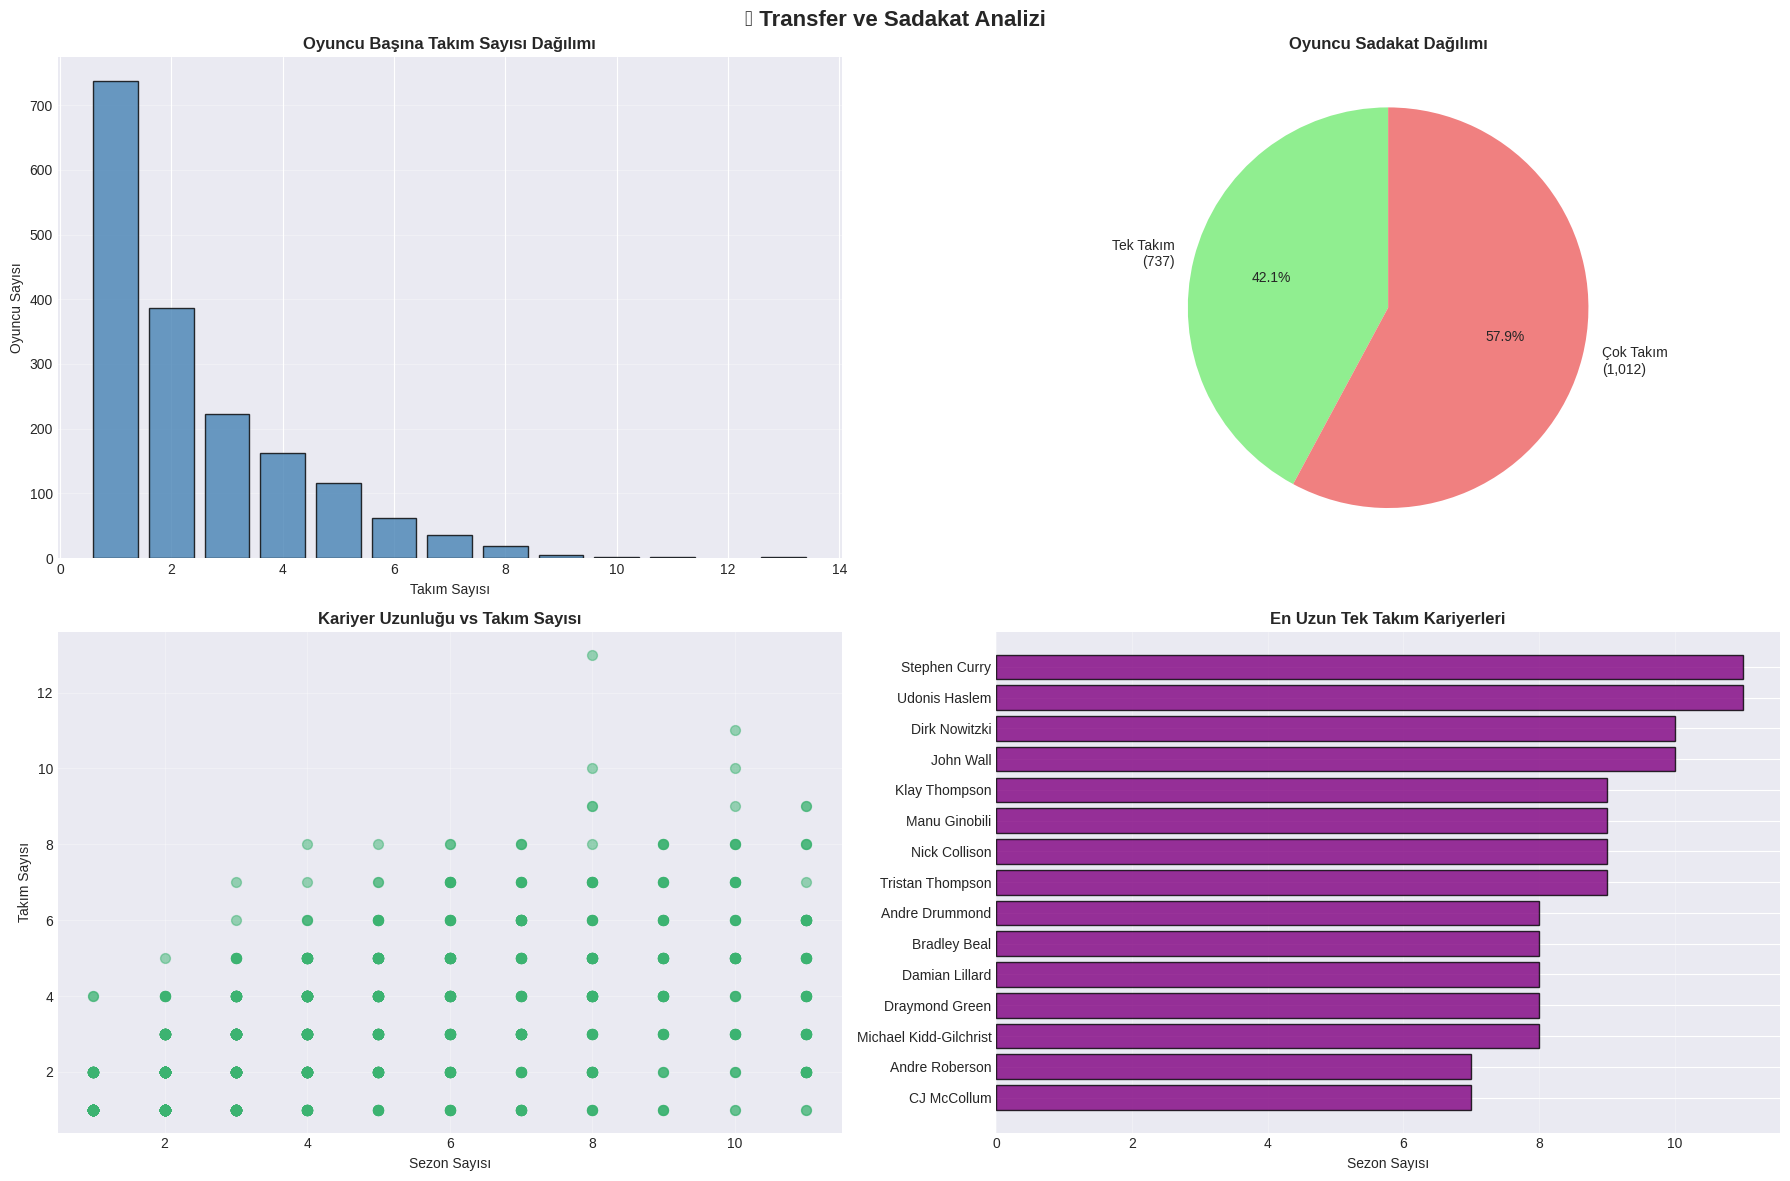

In [24]:
# Transfer analizi görselleştirme
if 'num_teams' in loyalty_analysis.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('🔄 Transfer ve Sadakat Analizi', fontsize=16, fontweight='bold')

    # 1. Takım sayısı dağılımı
    team_count_dist = loyalty_analysis['num_teams'].value_counts().sort_index()
    axes[0, 0].bar(team_count_dist.index, team_count_dist.values,
                  color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_title('Oyuncu Başına Takım Sayısı Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Takım Sayısı')
    axes[0, 0].set_ylabel('Oyuncu Sayısı')
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Sadakat pie chart
    one_team = len(one_team_players)
    multi_team = len(loyalty_analysis) - one_team
    axes[0, 1].pie([one_team, multi_team],
                  labels=[f'Tek Takım\n({one_team:,})', f'Çok Takım\n({multi_team:,})'],
                  autopct='%1.1f%%', startangle=90,
                  colors=['lightgreen', 'lightcoral'])
    axes[0, 1].set_title('Oyuncu Sadakat Dağılımı', fontweight='bold')

    # 3. Takım sayısı vs Sezon sayısı
    axes[1, 0].scatter(loyalty_analysis['num_seasons'], loyalty_analysis['num_teams'],
                      alpha=0.5, s=50, color='mediumseagreen')
    axes[1, 0].set_title('Kariyer Uzunluğu vs Takım Sayısı', fontweight='bold')
    axes[1, 0].set_xlabel('Sezon Sayısı')
    axes[1, 0].set_ylabel('Takım Sayısı')
    axes[1, 0].grid(alpha=0.3)

    # 4. En sadık oyuncular (uzun tek takım kariyerleri)
    top_loyalty = one_team_players.nlargest(15, 'num_seasons')
    axes[1, 1].barh(range(15), top_loyalty['num_seasons'].values,
                   color='purple', edgecolor='black', alpha=0.8)
    axes[1, 1].set_yticks(range(15))
    axes[1, 1].set_yticklabels(top_loyalty.index)
    axes[1, 1].set_xlabel('Sezon Sayısı')
    axes[1, 1].set_title('En Uzun Tek Takım Kariyerleri', fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 📊 İleri Düzey İstatistikler ve İçgörüler

In [25]:
# Takım bazında oyuncu rotasyonu
if all(col in df.columns for col in ['TEAM_ID', 'SEASON', 'PLAYER_NAME']):
    team_season_players = df.groupby(['TEAM_ID', 'SEASON'])['PLAYER_NAME'].nunique()

    print("="*70)
    print("🔄 TAKIM ROTASYON ANALİZİ")
    print("="*70)

    print(f"\n📊 Sezon Başına Oyuncu Sayısı (Takım Bazında):")
    print(f"  Ortalama: {team_season_players.mean():.2f} oyuncu/sezon")
    print(f"  Medyan: {team_season_players.median():.0f} oyuncu")
    print(f"  Min: {team_season_players.min()} oyuncu")
    print(f"  Max: {team_season_players.max()} oyuncu")
    print(f"  Std Sapma: {team_season_players.std():.2f}")

    # En çok ve en az oyuncu kullanan takım-sezonlar
    print(f"\n🔝 EN ÇOK OYUNCU KULLANAN TAKIM-SEZONLAR (Top 15):")
    top_rosters = team_season_players.nlargest(15)
    for idx, ((team, season), count) in enumerate(top_rosters.items(), 1):
        print(f"{idx:2d}. Team {team} - Sezon {season}: {count} oyuncu")

    print(f"\n🔻 EN AZ OYUNCU KULLANAN TAKIM-SEZONLAR (Top 15):")
    bottom_rosters = team_season_players.nsmallest(15)
    for idx, ((team, season), count) in enumerate(bottom_rosters.items(), 1):
        print(f"{idx:2d}. Team {team} - Sezon {season}: {count} oyuncu")

🔄 TAKIM ROTASYON ANALİZİ

📊 Sezon Başına Oyuncu Sayısı (Takım Bazında):
  Ortalama: 21.87 oyuncu/sezon
  Medyan: 22 oyuncu
  Min: 14 oyuncu
  Max: 33 oyuncu
  Std Sapma: 3.39

🔝 EN ÇOK OYUNCU KULLANAN TAKIM-SEZONLAR (Top 15):
 1. Team 1610612739 - Sezon 2018: 33 oyuncu
 2. Team 1610612755 - Sezon 2014: 33 oyuncu
 3. Team 1610612763 - Sezon 2015: 33 oyuncu
 4. Team 1610612740 - Sezon 2016: 32 oyuncu
 5. Team 1610612755 - Sezon 2013: 32 oyuncu
 6. Team 1610612763 - Sezon 2018: 32 oyuncu
 7. Team 1610612738 - Sezon 2014: 31 oyuncu
 8. Team 1610612755 - Sezon 2018: 30 oyuncu
 9. Team 1610612742 - Sezon 2016: 29 oyuncu
10. Team 1610612745 - Sezon 2017: 29 oyuncu
11. Team 1610612745 - Sezon 2018: 29 oyuncu
12. Team 1610612749 - Sezon 2017: 29 oyuncu
13. Team 1610612764 - Sezon 2018: 29 oyuncu
14. Team 1610612740 - Sezon 2015: 28 oyuncu
15. Team 1610612750 - Sezon 2014: 28 oyuncu

🔻 EN AZ OYUNCU KULLANAN TAKIM-SEZONLAR (Top 15):
 1. Team 1610612741 - Sezon 2011: 14 oyuncu
 2. Team 1610612743 

In [26]:
# Yıllık yeni oyuncu girişi (rookie analizi)
if all(col in df.columns for col in ['PLAYER_NAME', 'SEASON']):
    # Her oyuncunun ilk sezonu
    player_first_season = df.groupby('PLAYER_NAME')['SEASON'].min()

    # Sezonlara göre yeni oyuncu sayısı
    rookies_per_season = player_first_season.value_counts().sort_index()

    print("\n" + "="*70)
    print("🆕 YENİ OYUNCU (ROOKIE) ANALİZİ")
    print("="*70)

    print(f"\n📊 Sezonlara Göre Yeni Oyuncu Sayısı:")
    for season, count in rookies_per_season.items():
        print(f"  Sezon {season}: {count:3,} yeni oyuncu")

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Ort. Yeni Oyuncu/Sezon: {rookies_per_season.mean():.2f}")
    print(f"  Medyan: {rookies_per_season.median():.0f}")
    print(f"  En fazla: {rookies_per_season.max()} ({rookies_per_season.idxmax()})")
    print(f"  En az: {rookies_per_season.min()} ({rookies_per_season.idxmin()})")


🆕 YENİ OYUNCU (ROOKIE) ANALİZİ

📊 Sezonlara Göre Yeni Oyuncu Sayısı:
  Sezon 2009: 510 yeni oyuncu
  Sezon 2010: 113 yeni oyuncu
  Sezon 2011: 108 yeni oyuncu
  Sezon 2012: 108 yeni oyuncu
  Sezon 2013: 103 yeni oyuncu
  Sezon 2014: 112 yeni oyuncu
  Sezon 2015: 133 yeni oyuncu
  Sezon 2016: 124 yeni oyuncu
  Sezon 2017: 140 yeni oyuncu
  Sezon 2018: 142 yeni oyuncu
  Sezon 2019: 156 yeni oyuncu

📊 Genel İstatistikler:
  Ort. Yeni Oyuncu/Sezon: 159.00
  Medyan: 124
  En fazla: 510 (2009)
  En az: 103 (2013)


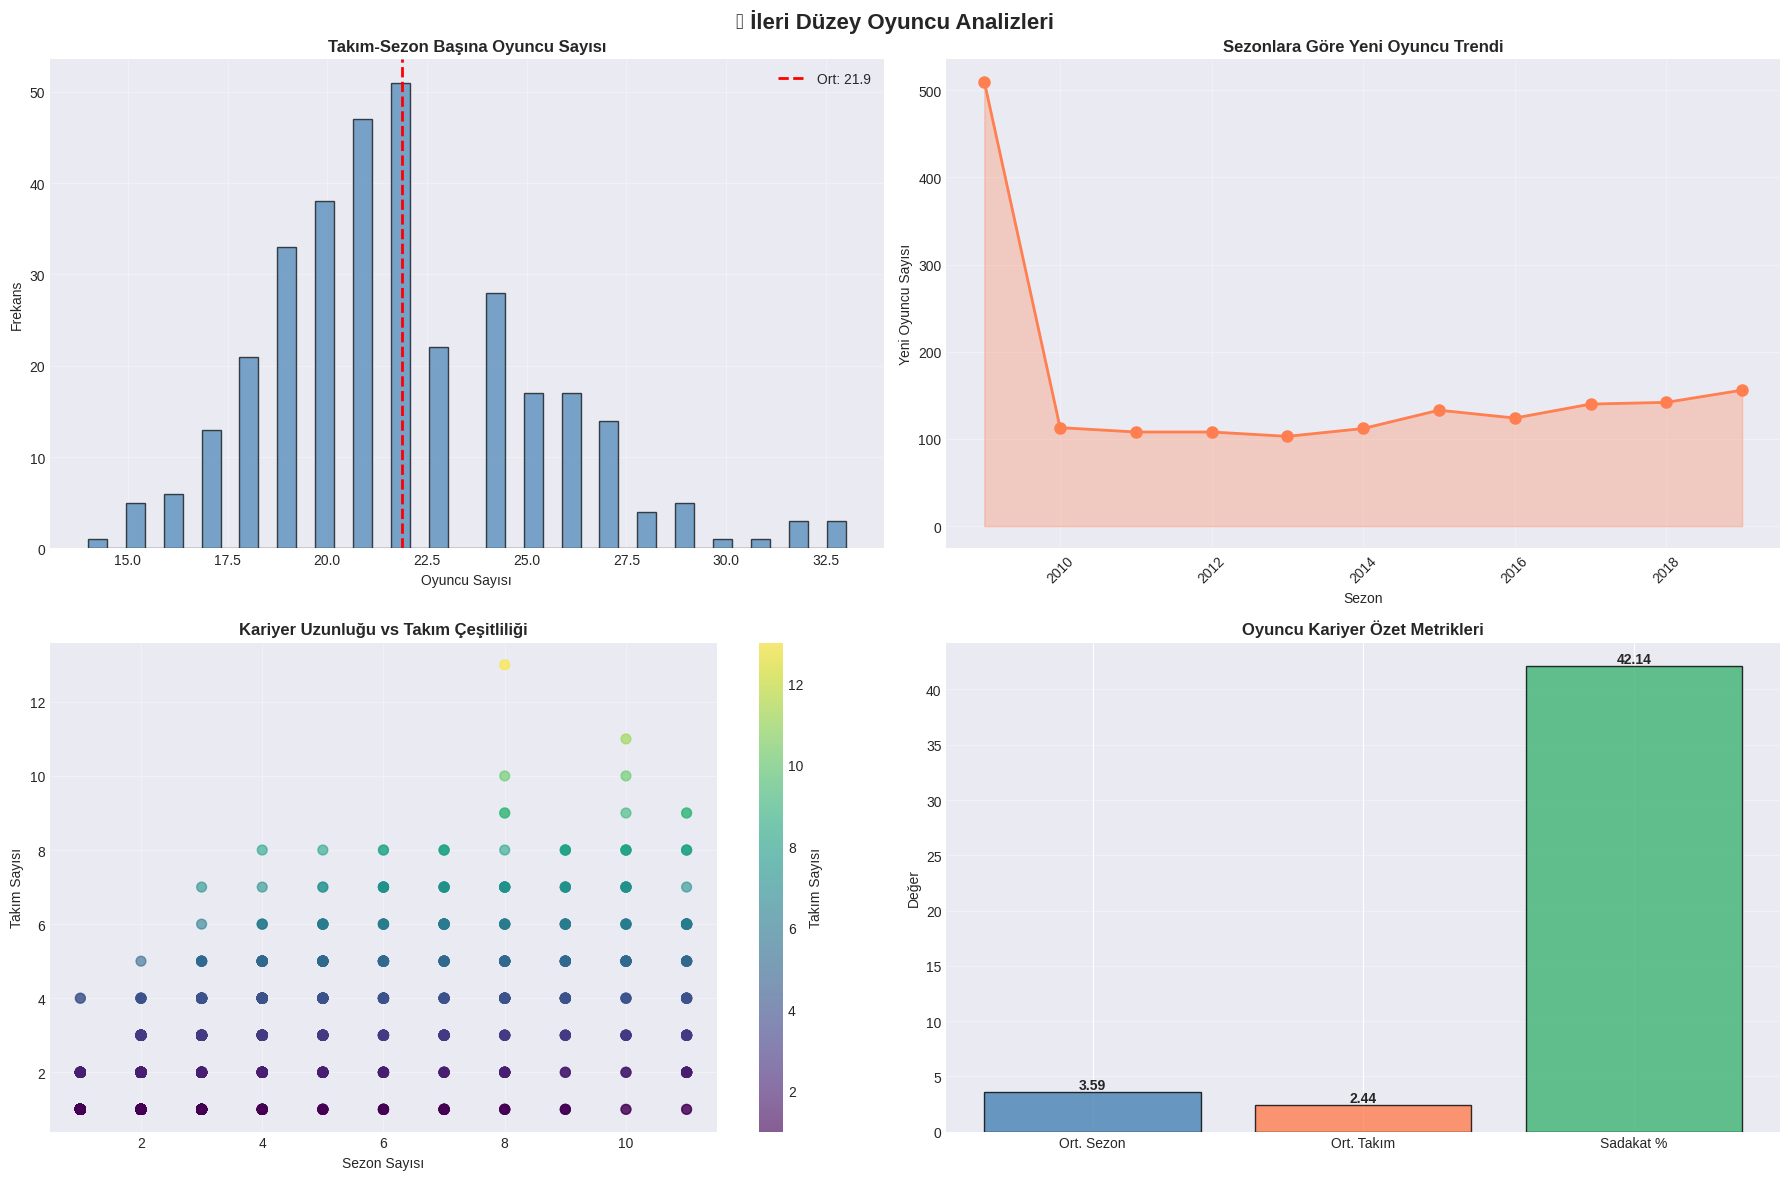

In [27]:
# İleri düzey görselleştirmeler
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('📊 İleri Düzey Oyuncu Analizleri', fontsize=16, fontweight='bold')

# 1. Takım rotasyon dağılımı
if 'team_season_players' in locals():
    axes[0, 0].hist(team_season_players.values, bins=40, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(team_season_players.mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {team_season_players.mean():.1f}")
    axes[0, 0].set_title('Takım-Sezon Başına Oyuncu Sayısı', fontweight='bold')
    axes[0, 0].set_xlabel('Oyuncu Sayısı')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# 2. Yıllık rookie sayısı trendi
if 'rookies_per_season' in locals():
    axes[0, 1].plot(rookies_per_season.index, rookies_per_season.values,
                   marker='o', linewidth=2, markersize=8, color='coral')
    axes[0, 1].fill_between(rookies_per_season.index, rookies_per_season.values,
                            alpha=0.3, color='coral')
    axes[0, 1].set_title('Sezonlara Göre Yeni Oyuncu Trendi', fontweight='bold')
    axes[0, 1].set_xlabel('Sezon')
    axes[0, 1].set_ylabel('Yeni Oyuncu Sayısı')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Kariyer vs Takım scatter (farklı renklendirme)
if 'loyalty_analysis' in locals():
    scatter = axes[1, 0].scatter(loyalty_analysis['num_seasons'],
                                loyalty_analysis['num_teams'],
                                c=loyalty_analysis['num_teams'],
                                cmap='viridis', alpha=0.6, s=50)
    plt.colorbar(scatter, ax=axes[1, 0], label='Takım Sayısı')
    axes[1, 0].set_title('Kariyer Uzunluğu vs Takım Çeşitliliği', fontweight='bold')
    axes[1, 0].set_xlabel('Sezon Sayısı')
    axes[1, 0].set_ylabel('Takım Sayısı')
    axes[1, 0].grid(alpha=0.3)

# 4. Oyuncu dağılım özeti
if 'seasons_per_player' in locals() and 'teams_per_player' in locals():
    summary_data = [
        seasons_per_player.mean(),
        teams_per_player.mean(),
        len(one_team_players) / len(loyalty_analysis) * 100
    ]
    labels = ['Ort. Sezon', 'Ort. Takım', 'Sadakat %']
    colors_bar = ['steelblue', 'coral', 'mediumseagreen']

    bars = axes[1, 1].bar(range(3), summary_data, color=colors_bar,
                         edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(3))
    axes[1, 1].set_xticklabels(labels)
    axes[1, 1].set_title('Oyuncu Kariyer Özet Metrikleri', fontweight='bold')
    axes[1, 1].set_ylabel('Değer')
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Değerleri barların üstüne yaz
    for bar, val in zip(bars, summary_data):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 PLAYERS.CSV - Kapsamlı Özet Raporu

In [28]:
# Final kapsamlı özet
print("\n" + "="*80)
print("📝 PLAYERS.CSV - KAPSAMLI ÖZET RAPOR")
print("="*80)

print(f"\n🎯 VERİ SETİ:")
print(f"  • Toplam Kayıt: {len(df):,}")
print(f"  • Sütun Sayısı: {len(df.columns)}")
print(f"  • Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'PLAYER_NAME' in df.columns:
    print(f"\n👥 OYUNCU BİLGİLERİ:")
    print(f"  • Benzersiz Oyuncu: {df['PLAYER_NAME'].nunique():,}")
    if 'name_length' in df.columns:
        print(f"  • Ort. İsim Uzunluğu: {df['name_length'].mean():.1f} karakter")
    if 'name_words' in df.columns:
        print(f"  • Ort. Kelime Sayısı: {df['name_words'].mean():.2f}")

if 'TEAM_ID' in df.columns:
    print(f"\n🏆 TAKIM BİLGİLERİ:")
    print(f"  • Benzersiz Takım: {df['TEAM_ID'].nunique()}")
    if 'teams_per_player' in locals():
        print(f"  • Ort. Takım/Oyuncu: {teams_per_player.mean():.2f}")
        print(f"  • Max Takım (tek oyuncu): {teams_per_player.max()}")

if 'SEASON' in df.columns:
    print(f"\n📅 SEZON BİLGİLERİ:")
    print(f"  • Sezon Sayısı: {df['SEASON'].nunique()}")
    print(f"  • Sezon Aralığı: {df['SEASON'].min()} - {df['SEASON'].max()}")
    if 'seasons_per_player' in locals():
        print(f"  • Ort. Kariyer Uzunluğu: {seasons_per_player.mean():.2f} sezon")
        print(f"  • En Uzun Kariyer: {seasons_per_player.max()} sezon")

if 'loyalty_analysis' in locals():
    print(f"\n💙 SADAKAT ANALİZİ:")
    print(f"  • Tek Takım Oyuncusu: {len(one_team_players):,}")
    print(f"  • Sadakat Oranı: {len(one_team_players)/len(loyalty_analysis)*100:.2f}%")
    print(f"  • Çok Takım Oyuncusu: {len(loyalty_analysis) - len(one_team_players):,}")

if 'rookies_per_season' in locals():
    print(f"\n🆕 ROOKIE ANALİZİ:")
    print(f"  • Ort. Yeni Oyuncu/Sezon: {rookies_per_season.mean():.2f}")
    print(f"  • En Fazla Rookie Sezonu: {rookies_per_season.idxmax()} ({rookies_per_season.max()} oyuncu)")

print(f"\n📊 VERİ KALİTESİ:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
print(f"  • Toplam Hücre: {total_cells:,}")
print(f"  • Eksik Hücre: {missing_cells:,}")
print(f"  • Eksiklik Oranı: {(missing_cells/total_cells*100):.2f}%")

print("\n" + "="*80)
print("✅ PLAYERS.CSV KAPSAMLI ANALİZİ TAMAMLANDI!")
print("="*80)
print("\n💡 Sonraki Adımlar:")
print("  • Oyuncu kariyer yolu analizleri yapın")
print("  • Transfer pattern'leri keşfedin")
print("  • Takım roster optimizasyonu çalışmaları")
print("  • Oyuncu-takım uyum analizleri")
print("  • Network graph analizleri (oyuncu-takım ilişkileri)")
print("\n" + "="*80)


📝 PLAYERS.CSV - KAPSAMLI ÖZET RAPOR

🎯 VERİ SETİ:
  • Toplam Kayıt: 7,228
  • Sütun Sayısı: 6
  • Bellek: 0.70 MB

👥 OYUNCU BİLGİLERİ:
  • Benzersiz Oyuncu: 1,749
  • Ort. İsim Uzunluğu: 12.9 karakter
  • Ort. Kelime Sayısı: 2.03

🏆 TAKIM BİLGİLERİ:
  • Benzersiz Takım: 30
  • Ort. Takım/Oyuncu: 2.44
  • Max Takım (tek oyuncu): 13

📅 SEZON BİLGİLERİ:
  • Sezon Sayısı: 11
  • Sezon Aralığı: 2009 - 2019
  • Ort. Kariyer Uzunluğu: 3.59 sezon
  • En Uzun Kariyer: 11 sezon

💙 SADAKAT ANALİZİ:
  • Tek Takım Oyuncusu: 737
  • Sadakat Oranı: 42.14%
  • Çok Takım Oyuncusu: 1,012

🆕 ROOKIE ANALİZİ:
  • Ort. Yeni Oyuncu/Sezon: 159.00
  • En Fazla Rookie Sezonu: 2009 (510 oyuncu)

📊 VERİ KALİTESİ:
  • Toplam Hücre: 43,368
  • Eksik Hücre: 0
  • Eksiklik Oranı: 0.00%

✅ PLAYERS.CSV KAPSAMLI ANALİZİ TAMAMLANDI!

💡 Sonraki Adımlar:
  • Oyuncu kariyer yolu analizleri yapın
  • Transfer pattern'leri keşfedin
  • Takım roster optimizasyonu çalışmaları
  • Oyuncu-takım uyum analizleri
  • Network graph 